# Notebook 3C — Uncertainty for a Neural Network

*Day 5b · Student C — read a per-star uncertainty out of your network with a deep ensemble, calibrate it, and find where it still lies.*

In [1]:
# ======================================================================================
# Setup — run this first (you don't need to read it closely).
# It imports a few libraries, sets a shared plot style, and defines the helper functions used
# throughout the notebook (load_data, the plot helpers, the metric helpers, ...).  These are the
# SAME helpers in every notebook, so your results line up with your teammates'.  If a later cell
# says a helper is "not defined", you probably skipped this cell — run it, then carry on.
# ======================================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------------------------
# Paths — resolved so the notebooks work whether they're run from the materials folder or
# from solutions/ .  Outputs and figures always land in the materials root.
# ----------------------------------------------------------------------------------------
def _materials_root():
    """Folder that contains data/ ; searched upward from the working directory."""
    here = os.path.abspath(os.getcwd())
    for d in [here, os.path.dirname(here), os.path.dirname(os.path.dirname(here))]:
        if os.path.isdir(os.path.join(d, "data")):
            return d
    return here

ROOT = _materials_root()
DATA_DIR = os.path.join(ROOT, "data")
OUTPUTS_DIR = os.path.join(ROOT, "outputs")
FIGURES_DIR = os.path.join(ROOT, "figures")
MODELS_DIR = os.path.join(ROOT, "models")     # fitted models saved to disk (experiment tracking)
for _d in (DATA_DIR, OUTPUTS_DIR, FIGURES_DIR, MODELS_DIR):
    os.makedirs(_d, exist_ok=True)

# Module-level cache of the reconstruction basis (set by load_data; used by reconstruct_spectrum).
_RECON = {"wavelength": None, "basis": None, "is_mock": True, "Xerr": None}
_RAW_CACHE = {}   # path -> full arrays, so repeated load_data() calls don't re-read the file

# Default working-set size.  The real catalog is ~200k stars; we train on a fast deterministic
# subsample by default so in-class fits stay quick AND every notebook sees the SAME stars (which
# keeps the NB2->NB3->NB4 saved-prediction hand-off aligned).  Pass n=None to use the WHOLE
# high-quality catalog (the "does more data help?" / label-transfer-at-scale exercise).
DEFAULT_N = 30000

# Canonical label columns.  The modelling track predicts [Fe/H]; Teff & logg are explored and
# used as the axes for residual / coverage maps.  alpha/age/dist are extra "explore" labels.
LABEL_COLS = ["Teff", "logg", "FeH", "alpha", "age", "dist"]
PRETTY = {"Teff": r"$T_\mathrm{eff}$ [K]", "logg": r"$\log g$ [dex]",
          "FeH": r"[Fe/H] [dex]", "alpha": r"[$\alpha$/M] [dex]",
          "age": "age [Gyr]", "dist": "distance [pc]"}


# ========================================================================================
# Plot style
# ========================================================================================
def set_plot_style():
    """Consistent, readable matplotlib defaults.  Called once in setup."""
    plt.rcParams.update({
        "figure.figsize": (6.4, 4.4), "figure.dpi": 110, "savefig.dpi": 150,
        "savefig.bbox": "tight", "font.size": 12, "axes.titlesize": 13,
        "axes.labelsize": 12, "axes.grid": True, "grid.alpha": 0.25,
        "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
        "legend.frameon": False, "legend.fontsize": 11, "lines.linewidth": 2.0,
        "scatter.edgecolors": "none", "image.cmap": "viridis",
    })

# A small colour-blind-friendly palette used across the materials for named series.
COLORS = {"linear": "#888888", "knn": "#0072B2", "rf": "#009E73",
          "nn": "#D55E00", "native": "#0072B2", "conformal": "#D55E00",
          "truth": "#222222", "accent": "#CC79A7"}


# ========================================================================================
# Data loading  (the mock generator lives here so the shipped npz and the on-the-fly
# fallback are guaranteed identical)
# ========================================================================================
_C2_NM = 1.438777e7  # second radiation constant hc/k in nm*K


def _build_basis(wave_min=336.0, wave_max=1020.0, n_wave=343, n_bp=55, n_rp=55):
    """Smooth windowed-cosine modes per band, orthonormalised.  Low modes are broad
    (continuum), high modes wiggly (fine structure).  reconstruct = B @ coeff."""
    wave = np.linspace(wave_min, wave_max, n_wave)
    cols = []
    def band(lo, hi, n_modes):
        x = (wave - lo) / (hi - lo)
        win = np.where((x >= 0) & (x <= 1), np.sin(np.clip(x, 0, 1) * np.pi) ** 0.5, 0.0)
        for j in range(n_modes):
            cols.append(np.cos(j * np.pi * np.clip(x, 0, 1)) * win)
    band(wave_min, 690.0, n_bp)
    band(630.0, wave_max, n_rp)
    Q, _ = np.linalg.qr(np.column_stack(cols))
    return wave, Q[:, :n_bp + n_rp]


def _synthesize_mock(n=50000, seed=42):
    """
    # MOCK DATA — swap for the real Zenodo loader.
    Physically-motivated synthetic stand-in for the Laroche & Speagle APOGEE x Gaia-XP
    cross-match.  Returns the same dict that the shipped npz stores.  See the build spec
    and _build/make_mock_dataset.py for the full rationale.  In one sentence: a Planck
    continuum sets Teff; Balmer lines reinforce Teff; gravity-sensitive molecular bands
    carry log g; SHALLOW metal lines (suppressed at high Teff) carry the hard, heteroscedastic
    [Fe/H]; reddening + hidden factors add a realistic irreducible (aleatoric) floor.
    """
    rng = np.random.default_rng(seed)
    wave, B = _build_basis()
    W = wave.size

    # --- labels with Kiel-diagram structure: dwarfs + giants + red clump + metal-poor halo ---
    is_giant = rng.random(n) < 0.45
    Teff = np.empty(n); logg = np.empty(n); FeH = np.empty(n)
    nd, ng = np.count_nonzero(~is_giant), np.count_nonzero(is_giant)
    Td = 4000 + 3100 * rng.beta(1.5, 2.5, nd)
    Teff[~is_giant] = Td
    logg[~is_giant] = 4.62 - 0.00013 * (Td - 4500) + rng.normal(0, 0.10, nd)
    FeH[~is_giant] = rng.normal(-0.05, 0.25, nd)
    Tg = 3800 + 1700 * rng.beta(2.0, 2.3, ng)
    Teff[is_giant] = Tg
    logg[is_giant] = 1.7 + 0.00095 * (Tg - 3800) + rng.normal(0, 0.33, ng)
    FeH[is_giant] = rng.normal(-0.28, 0.34, ng)
    clump = is_giant & (rng.random(n) < 0.33); nc = np.count_nonzero(clump)
    Teff[clump] = rng.normal(4800, 140, nc); logg[clump] = rng.normal(2.45, 0.11, nc)
    FeH[clump] = rng.normal(-0.10, 0.20, nc)
    halo = rng.random(n) < 0.06; nh = np.count_nonzero(halo)
    Teff[halo] = rng.normal(4900, 450, nh)
    logg[halo] = np.clip(rng.normal(2.2, 0.7, nh), 0.5, 3.6)
    FeH[halo] = rng.normal(-1.45, 0.45, nh)
    is_giant = is_giant | halo
    Teff = np.clip(Teff, 3500, 7600); logg = np.clip(logg, 0.3, 5.0); FeH = np.clip(FeH, -2.4, 0.55)
    alpha = np.clip(0.13 - 0.24 * FeH + rng.normal(0, 0.035, n), -0.05, 0.5)
    age = np.clip(2.0 + 6.5 * is_giant - 3.5 * FeH + rng.normal(0, 1.8, n), 0.3, 13.5)
    dist = np.exp(rng.normal(6.7, 0.9, n)) * (1.0 + 1.5 * is_giant)

    # --- forward model: labels -> flux ---
    def gauss(c, w): return np.exp(-0.5 * ((wave - c) / w) ** 2)
    x = _C2_NM / (wave[None, :] * Teff[:, None])
    flux = wave[None, :] ** -5 / np.expm1(np.clip(x, 1e-6, 700))
    flux = flux / flux.mean(axis=1, keepdims=True)
    jump = 1.0 / (1.0 + np.exp((wave - 382.0) / 6.0))
    flux *= 1.0 - (0.18 * np.clip((Teff - 5200) / 2500, 0, 1.4) * (1 + 0.15 * (4.5 - logg)))[:, None] * jump[None, :]
    balmer = sum(a * gauss(c, 9.0) for c, a in [(434., .9), (486.1, 1.1), (656.3, 1.)])
    bstr = np.clip(np.exp((Teff - 5200) / 1500), 0.15, 6.0) * (1 + 0.12 * (4.5 - logg))
    flux *= 1.0 - 0.012 * bstr[:, None] * balmer[None, :]
    g_dwarf = np.clip(logg - 3.0, 0, 2.0)[:, None]; g_giant = np.clip(3.6 - logg, 0, 3.2)[:, None]
    coolf = np.clip((5500 - Teff) / 2000.0, 0.2, 1.4)[:, None]
    grav = np.zeros((n, W))
    for c, a in [(488., 1.), (521., .9), (692., .8)]: grav += a * g_dwarf * gauss(c, 15.)[None, :]
    for c, a in [(421., .9), (793., .8), (883., 1.)]: grav += a * g_giant * gauss(c, 17.)[None, :]
    flux *= 1.0 - 0.038 * coolf * grav
    metal = sum(a * gauss(c, 11.0) for c, a in
                [(422.7, 1.), (460., .7), (517.3, 1.2), (527., .9), (589.3, 1.1),
                 (670.8, .6), (770., .6), (850., .8), (920., .5)])
    # Line depth scales with metal abundance (metal-poor stars have WEAK lines -> little [Fe/H]
    # information -> the dominant, physically-correct source of heteroscedastic [Fe/H] error).
    # Temperature only mildly suppresses lines; gravity gives luminous giants slightly weaker,
    # more variable lines (they are also the sparsest, most-extrapolated regime).
    mstr = 10.0 ** (0.55 * FeH)
    tsupp = np.clip(np.exp(-(Teff - 4500) / 4800.0), 0.6, 1.25)
    line_amp = (mstr * tsupp * np.clip(0.7 + 0.22 * logg, 0.7, 1.4))[:, None]
    flux *= 1.0 - 0.045 * line_amp * metal[None, :]
    ebv = np.abs(rng.normal(0, 0.11, n))[:, None]
    ext = (550.0 / wave) ** 1.0
    flux *= 10.0 ** (-0.4 * 1.6 * ebv * (ext / ext.mean())[None, :])
    P = np.column_stack([np.sin(f * np.pi * (wave - wave[0]) / (wave[-1] - wave[0])) for f in (1.5, 3.5, 6.5)])
    flux *= 1.0 + 0.004 * (rng.normal(0, 1, (n, 3)) @ P.T)
    gflux = np.exp(rng.normal(0.0, 0.8, n))
    snr = np.clip(58 * gflux ** 0.30 * np.exp(rng.normal(0, 0.30, n)), 20, 400)
    obs = gflux[:, None] * np.clip(flux, 1e-3, None)
    noise_std = obs.mean(axis=1, keepdims=True) / snr[:, None]        # photon-noise std (per star)
    obs = obs + rng.normal(0, 1, obs.shape) * noise_std
    X = (obs @ B).astype(np.float32)
    # per-coefficient measurement error on the RAW coefficients (the orthonormal basis preserves the
    # per-component noise std) — used by the NB3 input-Monte-Carlo stretch.
    Xerr = np.repeat(noise_std, 110, axis=1).astype(np.float32)
    return dict(X=X, Xerr=Xerr, Teff=Teff, logg=logg, FeH=FeH, alpha=alpha, age=age, dist=dist,
                snr=snr, gflux=gflux, source_id=(1_000_000_000 + np.arange(n)),
                wavelength=wave, basis=B.astype(np.float32), is_mock=True)


def load_data(path=None, n=DEFAULT_N, seed=0, verbose=True):
    """
    Load the dataset in one line:  X, y, meta = load_data()

    Parameters
    ----------
    n    : working-set size.  Returns a deterministic random subsample of `n` stars (default
           DEFAULT_N=30000) so fits are fast and every notebook sees the same stars.  Pass
           `n=None` to use the ENTIRE high-quality catalog (the scale-up exercise) — slower.
    seed : seed for the subsample (keep it fixed so the NB2->NB3->NB4 hand-off stays aligned).

    Returns
    -------
    X    : float array, shape (n, 110) — the Gaia XP coefficients (55 BP + 55 RP).
    y    : DataFrame with columns Teff, logg, FeH (+ alpha, dist) — the labels.
    meta : DataFrame with source_id, snr, gflux — per-star bookkeeping (gflux is the
           brightness scale used by normalize_by_g).
    """
    if path is None:
        for cand in ("xp_apogee_real.npz", "xp_apogee_mock.npz"):
            p = os.path.join(DATA_DIR, cand)
            if os.path.exists(p):
                path = p
                break
    key = path if path is not None else "__synth__"
    if key in _RAW_CACHE:
        data = _RAW_CACHE[key]
    elif path is not None and os.path.exists(path):
        d = np.load(path, allow_pickle=True)
        data = {k: d[k] for k in d.files}
        _RAW_CACHE[key] = data
    else:
        if verbose:
            print("No data file found — synthesising the mock dataset on the fly.")
        data = _synthesize_mock()
        _RAW_CACHE[key] = data
    is_mock = bool(data.get("is_mock", True))
    src = os.path.basename(path) if path else "synthesised mock"

    _RECON["wavelength"] = np.asarray(data["wavelength"], float)
    _RECON["basis"] = np.asarray(data["basis"], float)
    _RECON["is_mock"] = is_mock

    X_all = np.asarray(data["X"], dtype=float)
    N = X_all.shape[0]
    if n is not None and n < N:
        sel = np.sort(np.random.default_rng(seed).permutation(N)[:n])
    else:
        sel = np.arange(N)
    X = X_all[sel]
    _RECON["Xerr"] = np.asarray(data["Xerr"], float)[sel] if "Xerr" in data else None  # for input-MC (NB3)
    y = pd.DataFrame({c: np.asarray(data[c], float)[sel] for c in LABEL_COLS if c in data})
    meta = pd.DataFrame({k: np.asarray(data[k]).ravel()[sel] for k in ("source_id", "snr", "gflux") if k in data})
    if verbose:
        tag = "MOCK (synthetic)" if is_mock else "REAL (Gaia XP x APOGEE)"
        extra = f" (subsampled from {N:,}; pass n=None for all)" if len(sel) < N else ""
        print(f"Loaded {src}: {tag}  —  {X.shape[0]:,} stars{extra}, {X.shape[1]} coefficients.")
    return X, y, meta


# ========================================================================================
# Spectrum reconstruction
# ========================================================================================
def load_input_errors():
    """Per-coefficient measurement errors for the stars from the LAST `load_data()` call (same rows,
    same order, same (n, 110) shape as the `X` you just loaded) — on the RAW coefficient scale.
    For the NB3 input-Monte-Carlo stretch:  X_perturbed = X + rng.normal(0, load_input_errors()).
    Returns None if the dataset has no stored errors (call `load_data()` first)."""
    if _RECON["Xerr"] is None:
        load_data(verbose=False)
    return _RECON["Xerr"]


def reconstruct_spectrum(coeffs):
    """
    Turn a star's 110 XP coefficients into a sampled spectrum: returns (wavelength_nm, flux).
    Accepts a single (110,) vector or an (M, 110) batch.

    On the shipped data this uses the stored smooth basis (B @ coeff) — no extra packages.

    # REAL DATA: with the genuine Gaia archive continuous representation you would instead
    # reconstruct with GaiaXPy, e.g.:
    #     from gaiaxpy import calibrate
    #     sampling = np.arange(336, 1021, 2.0)              # nm
    #     spectra, sampled_wl = calibrate(source_dataframe, sampling=sampling, save_file=False)
    # The stored basis is recovered from Zenodo's wavelength-space spectra at curation time
    # (see _build/prepare_real_data.py), so this helper stays identical for mock and real.
    """
    if _RECON["basis"] is None:
        load_data(verbose=False)
    B, wave = _RECON["basis"], _RECON["wavelength"]
    coeffs = np.asarray(coeffs, float)
    flux = coeffs @ B.T
    return wave, flux


# ========================================================================================
# Preprocessing recipe:  normalize by the G-band  ->  standardize (fit on train only)
# ========================================================================================
def normalize_by_g(X, g):
    """Divide each star's coefficients by its G-band brightness scale `g` (a column of meta).
    Removes brightness/distance and keeps the spectral SHAPE — what carries the labels."""
    g = np.asarray(g, float).reshape(-1, 1)
    return np.asarray(X, float) / g


def standardize(X_train, X_other):
    """Z-score the coefficients using statistics from the TRAINING set only, then apply the
    same shift/scale to another split.  Returns (X_train_scaled, X_other_scaled).
    (Equivalent to sklearn's StandardScaler fit on train; spelled out for clarity.)"""
    mu = X_train.mean(axis=0, keepdims=True)
    sd = X_train.std(axis=0, keepdims=True)
    sd = np.where(sd < 1e-12, 1.0, sd)
    return (X_train - mu) / sd, (X_other - mu) / sd


# ========================================================================================
# Splitting  (fixed seed so every student gets the same train / cal / test stars)
# ========================================================================================
def train_cal_test_split(X, y, seed=0, fracs=(0.6, 0.2, 0.2)):
    """Reproducible 60/20/20 split into train / calibration / test.
    Returns a dict with X_* arrays, y_* DataFrames, and idx_* index arrays.
    Calibration is held out for the uncertainty work in NB3/NB4."""
    X = np.asarray(X, float)
    y = y.reset_index(drop=True)
    n = X.shape[0]
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    n_tr = int(fracs[0] * n); n_ca = int(fracs[1] * n)
    i_tr, i_ca, i_te = idx[:n_tr], idx[n_tr:n_tr + n_ca], idx[n_tr + n_ca:]
    return {
        "X_train": X[i_tr], "X_cal": X[i_ca], "X_test": X[i_te],
        "y_train": y.iloc[i_tr].reset_index(drop=True),
        "y_cal": y.iloc[i_ca].reset_index(drop=True),
        "y_test": y.iloc[i_te].reset_index(drop=True),
        "idx_train": i_tr, "idx_cal": i_ca, "idx_test": i_te,
    }


# ========================================================================================
# Models — the four estimators the students compare.  Defined ONCE here so NB2, NB3 and NB4
# build byte-identical models, which is what lets predictions and intervals line up across
# notebooks and across the three students.  Each is a Pipeline(StandardScaler + estimator),
# so you feed it the G-normalized coefficients and it standardizes internally (fit on train).
# ========================================================================================
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

MODEL_NAMES = {"linear": "Linear regression (baseline)", "knn": "K-nearest neighbors",
               "rf": "Random forest", "nn": "Neural network (MLP)"}

def make_model(name, **overrides):
    """Canonical Pipeline(StandardScaler + estimator) for a model name in {linear,knn,rf,nn}.
    Pass overrides to tune one knob, e.g. make_model('knn', n_neighbors=20).  The step name for
    the estimator is its lowercased class name (e.g. 'kneighborsregressor') — handy in NB3 when
    you reach inside the fitted pipeline for a model-native uncertainty."""
    if name == "linear":
        est = LinearRegression(**overrides)
    elif name == "knn":
        est = KNeighborsRegressor(**{"n_neighbors": 12, **overrides})
    elif name == "rf":
        est = RandomForestRegressor(**{"n_estimators": 150, "min_samples_leaf": 3,
                                       "random_state": 0, "n_jobs": -1, **overrides})
    elif name == "nn":
        est = MLPRegressor(**{"hidden_layer_sizes": (64, 64), "alpha": 1e-3, "max_iter": 500,
                              "early_stopping": True, "random_state": 0, **overrides})
    else:
        raise ValueError(f"unknown model '{name}' (use one of {list(MODEL_NAMES)})")
    return make_pipeline(StandardScaler(), est)


# ========================================================================================
# Metrics
# ========================================================================================
def regression_metrics(y_true, y_pred):
    """Return a dict of RMSE, MAE, bias (mean signed error), and R^2."""
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    err = y_pred - y_true
    ss_res = float(np.sum(err ** 2))
    ss_tot = float(np.sum((y_true - y_true.mean()) ** 2)) or 1.0
    return {"RMSE": float(np.sqrt(np.mean(err ** 2))), "MAE": float(np.mean(np.abs(err))),
            "bias": float(np.mean(err)), "R2": float(1.0 - ss_res / ss_tot)}


# ========================================================================================
# Plots — predictions & residuals
# ========================================================================================
def plot_pred_vs_true(y_true, y_pred, title=None, ax=None, color=None, label=None, units=""):
    """Scatter of predicted vs true with the 1:1 line and an RMSE annotation."""
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    if ax is None:
        _, ax = plt.subplots()
    lo = min(y_true.min(), y_pred.min()); hi = max(y_true.max(), y_pred.max())
    pad = 0.04 * (hi - lo + 1e-9)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "--", color="0.4", lw=1.3, zorder=1)
    ax.scatter(y_true, y_pred, s=8, alpha=0.35, color=color or COLORS["rf"], label=label, zorder=2)
    m = regression_metrics(y_true, y_pred)
    ax.text(0.04, 0.96, f"RMSE = {m['RMSE']:.3g}{units}\nbias = {m['bias']:+.2g}{units}",
            transform=ax.transAxes, va="top", ha="left", fontsize=10,
            bbox=dict(boxstyle="round", fc="white", ec="0.8", alpha=0.85))
    ax.set_xlabel(f"true{(' ' + units) if units else ''}")
    ax.set_ylabel(f"predicted{(' ' + units) if units else ''}")
    ax.set_xlim(lo - pad, hi + pad); ax.set_ylim(lo - pad, hi + pad)
    ax.set_aspect("equal", "box")
    if title:
        ax.set_title(title)
    if label:
        ax.legend(loc="lower right")
    return ax


def plot_residuals(y_true, y_pred, feature=None, feature_name="value", ax=None, color=None):
    """Residuals (pred - true) vs the truth, or vs an external `feature` (e.g. Teff).
    A flat band around zero means well-behaved errors; trends/fans flag structure."""
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    resid = y_pred - y_true
    xx = np.asarray(feature, float) if feature is not None else y_true
    xlabel = feature_name if feature is not None else "true value"
    if ax is None:
        _, ax = plt.subplots()
    ax.axhline(0.0, color="0.4", ls="--", lw=1.3, zorder=1)
    ax.scatter(xx, resid, s=8, alpha=0.35, color=color or COLORS["rf"], zorder=2)
    ax.set_xlabel(xlabel); ax.set_ylabel("residual (pred − true)")
    return ax


# ========================================================================================
# Uncertainty — coverage, reliability, comparison
# ========================================================================================
def empirical_coverage(y_true, lower, upper):
    """Fraction of true values that fall inside [lower, upper]."""
    y_true = np.asarray(y_true, float)
    return float(np.mean((y_true >= np.asarray(lower, float)) & (y_true <= np.asarray(upper, float))))


def plot_reliability(y_true, lower, upper, target=None, feature=None, feature_name="bin",
                     n_bins=8, ax=None, color=None, label=None):
    """
    'Are the error bars honest, everywhere?'  Bins the points (by an external `feature` such
    as Teff if given, else by the interval centre) and plots empirical coverage per bin against
    the `target` line.  Bars sitting below the target reveal where intervals under-cover.
    """
    y_true = np.asarray(y_true, float)
    lower = np.asarray(lower, float); upper = np.asarray(upper, float)
    inside = (y_true >= lower) & (y_true <= upper)
    xx = np.asarray(feature, float) if feature is not None else 0.5 * (lower + upper)
    if ax is None:
        _, ax = plt.subplots()
    edges = np.quantile(xx, np.linspace(0, 1, n_bins + 1))
    edges[-1] += 1e-9
    centers, cov = [], []
    for i in range(n_bins):
        m = (xx >= edges[i]) & (xx < edges[i + 1])
        if m.sum() >= 5:
            centers.append(xx[m].mean()); cov.append(inside[m].mean())
    ax.plot(centers, cov, "o-", color=color or COLORS["native"], label=label)
    if target is not None:
        ax.axhline(target, color="0.4", ls="--", lw=1.3, label=f"target = {target:.0%}")
    ax.set_xlabel(feature_name if feature is not None else "interval centre")
    ax.set_ylabel("empirical coverage")
    ax.set_ylim(0, 1.02)
    if target is not None or label:
        ax.legend(loc="lower center")
    return ax


def compare_intervals(y_true, intervals, target=None, ax=None):
    """
    Compare several named interval sets.  `intervals` maps name -> (lower, upper).
    Draws two bars per method — coverage and median width — and returns a tidy summary table.
    """
    y_true = np.asarray(y_true, float)
    rows = []
    for name, (lo, hi) in intervals.items():
        rows.append({"method": name, "coverage": empirical_coverage(y_true, lo, hi),
                     "median_width": float(np.median(np.asarray(hi, float) - np.asarray(lo, float)))})
    tbl = pd.DataFrame(rows).set_index("method")
    if ax is None:
        _, ax = plt.subplots(1, 2, figsize=(9.5, 4.0))
    names = list(tbl.index)
    cols = [COLORS.get(n.split()[0].lower(), COLORS["accent"]) for n in names]
    ax[0].bar(names, tbl["coverage"], color=cols)
    if target is not None:
        ax[0].axhline(target, color="0.4", ls="--", lw=1.3, label=f"target = {target:.0%}")
        ax[0].legend()
    ax[0].set_ylabel("empirical coverage"); ax[0].set_ylim(0, 1.02); ax[0].set_title("Coverage")
    ax[1].bar(names, tbl["median_width"], color=cols)
    ax[1].set_ylabel("median interval width"); ax[1].set_title("Sharpness (narrower is better)")
    for a in ax:
        a.tick_params(axis="x", rotation=20)
    return tbl


# ========================================================================================
# Small convenience used in worked examples
# ========================================================================================
def savefig(name, fig=None):
    """Save a figure into figures/ for reuse on the poster.  Returns the path."""
    path = os.path.join(FIGURES_DIR, name)
    (fig or plt.gcf()).savefig(path)
    return path


def save_outputs(filename, **arrays):
    """Save named arrays into outputs/<filename> (the shared NB2->NB3->NB4 contract)."""
    path = os.path.join(OUTPUTS_DIR, filename)
    np.savez(path, **arrays)
    return path


def load_outputs(filename):
    """Load an outputs/ npz written by an earlier notebook; returns a dict of arrays."""
    d = np.load(os.path.join(OUTPUTS_DIR, filename), allow_pickle=True)
    return {k: d[k] for k in d.files}


# ----- Experiment tracking: save fitted models + log runs (so you can reproduce & compare) -----
def save_model(model, name):
    """Save a fitted model/pipeline to models/<name>.joblib. Returns the path.
    The point: a tuned model is an experiment result — persist it so NB3 can load the exact model
    you tuned (no silent refit), and so you can reproduce a run weeks later."""
    import joblib
    path = os.path.join(MODELS_DIR, f"{name}.joblib")
    joblib.dump(model, path)
    return path


def load_model(name):
    """Load a model previously saved with save_model(...)."""
    import joblib
    return joblib.load(os.path.join(MODELS_DIR, f"{name}.joblib"))


def log_experiment(name, params, metrics, filename=None):
    """Append one experiment run (its hyper-parameters + its metrics) to a CSV and return the full
    log as a DataFrame. This is the bare-bones version of what tools like MLflow / Weights & Biases
    do: a durable, comparable record of 'what did I try, and how did it score?'.
      params  : dict of hyper-parameters, e.g. {'n_neighbors': 12, 'weights': 'distance'}
      metrics : dict of scores, e.g. {'cv_rmse': 0.21, 'test_rmse': 0.20}
    """
    path = os.path.join(OUTPUTS_DIR, filename or f"{name}_experiments.csv")
    row = {"run": 1, **{f"param_{k}": v for k, v in params.items()}, **metrics}
    if os.path.exists(path):
        prev = pd.read_csv(path)
        row["run"] = int(prev["run"].max()) + 1 if "run" in prev else len(prev) + 1
        log = pd.concat([prev, pd.DataFrame([row])], ignore_index=True)
    else:
        log = pd.DataFrame([row])
    log.to_csv(path, index=False)
    return log

set_plot_style()
print('Setup complete — helpers ready.')


Setup complete — helpers ready.


## Welcome back — now give *your* neural network honest error bars

In the common notebook (03) the whole team built a **shared constant ± band** on the linear baseline,
tuned a fudge factor to hit 90% marginal coverage, and then watched it **under-cover the luminous
giants and the metal-poor stars** even after the average was fixed. That conditional gap is the thread
we keep pulling.

This is **your** lab, Student C. Your model is the **neural network** (`MLPRegressor`) you tuned in
Notebook 2C. Today you'll read an uncertainty **out of the network itself** — a *per-star* σ(x) that
can widen where stars are genuinely hard — calibrate it the same "tune on cal, report on test" way, and
check whether the conditional gap shrinks or survives.

The arc:

1. **The shared constant floor** on your network's predictions (the band to beat).
2. **Your native σ(x): a deep ensemble** — train a handful of networks with different seeds and read
   the *spread of their predictions* (you implement it).
3. **The fudge factor** — tune one scalar `c` on the calibration set so coverage hits 90%.
4. **Did it work?** — coverage, reliability by `log g` & `[Fe/H]`, width histogram.
5. **Explore** — is your uncertainty aleatoric or epistemic in flavour?
6. **Save** your native interval for Notebook 4.

Then three **optional stretches**, including a proper **Monte-Carlo dropout** network in PyTorch.

> Runs top-to-bottom as shipped. Every "your turn" cell already works — the task is to *implement* or
> *change* a marked piece and look again. If a cell errors, grab a TA.

## 0 · Load your tuned network and its predictions

Two things to load, and one rule:

- **`pipe = load_model("nn")`** — the *exact* network you tuned and saved in Notebook 2C. We **load it,
  never refit it from scratch** here, so the model you quantify is the model you tuned. (Notebook 2C
  saved it to `models/nn.joblib`.)
- **`d = load_outputs("nn_preds.npz")`** — its saved predictions on the calibration and test stars
  (keys `y_cal_true`, `y_cal_pred`, `y_test_true`, `y_test_pred`).

We also re-`load_data()` and redo the **same seed=0 split** to recover the test *features* (the saved
npz only stored the final numbers, and the deep ensemble in §2 needs the inputs).

The **calibration set** — the held-out chunk that is neither training nor test — is what we tune the
fudge factor on. It earns its keep again today.

In [2]:
import warnings
from scipy.stats import norm

MODEL = "nn"                              # this lab is the neural-network lab (Student C)
TARGET_LEVEL = 0.90                       # honest 90% intervals all day
k = norm.ppf((1 + TARGET_LEVEL) / 2)      # Gaussian multiplier: ~1.645 for 90% (a z-score)
print(f"MODEL = {MODEL!r}   nominal level = {TARGET_LEVEL:.0%}   k = {k:.3f}")

# Load the TUNED network (not a refit) and its saved predictions from Notebook 2C.
try:
    pipe = load_model(MODEL)                       # models/nn.joblib  -> the model you tuned
    d    = load_outputs(f"{MODEL}_preds.npz")      # outputs/nn_preds.npz -> its cal+test predictions
except FileNotFoundError:
    raise FileNotFoundError(
        "Missing models/nn.joblib or outputs/nn_preds.npz — run Notebook 2C (02c_tune_neural_net) "
        "first, then re-run this cell.")

# Re-create the SAME seed=0 split to recover the test/cal FEATURES (the npz only stored numbers).
X, y, meta = load_data(verbose=False)
Xn = normalize_by_g(X, meta["gflux"])              # brightness -> spectral shape (the recipe)
sp = train_cal_test_split(Xn, y, seed=0)           # same split as NB2 -> rows align with saved preds
y_train_feh = sp["y_train"]["FeH"].to_numpy()
y_cal_feh   = sp["y_cal"]["FeH"].to_numpy()
y_test_feh  = sp["y_test"]["FeH"].to_numpy()
logg_test   = sp["y_test"]["logg"].to_numpy()
feh_test    = sp["y_test"]["FeH"].to_numpy()

# Tripwire: saved preds must line up row-for-row with this split (fix NB2 if it fires; don't relax it).
assert np.allclose(sp["y_test"]["FeH"].to_numpy(), d["y_test_true"]), "row order mismatch with saved preds!"
print(f"loaded tuned nn + preds | calibration stars: {d['y_cal_true'].size:,}   test stars: {d['y_test_true'].size:,}")

MODEL = 'nn'   nominal level = 90%   k = 1.645


loaded tuned nn + preds | calibration stars: 6,000   test stars: 6,000


## 1 · The shared constant floor on your network

Start with the band everyone built in the common notebook, now on **your network's** residuals — the
floor your native interval has to beat.

The recipe (from 03 §3): measure one residual scatter **σ on the held-out calibration set** (honest —
the network never fit those stars), then draw the *same* `± k·σ` band on every test star.

> **⚠ Calibration residuals, not training residuals.** Training residuals are optimistically small
> (the network fit those points); the calibration set is held out, so σ measured on it is honest.

Its built-in weakness, stated up front: **one width for every star** (homoscedastic). It *cannot* widen
for the genuinely harder stars — which is exactly the gap your per-star native σ will try to close.

In [3]:
# Residuals on the HELD-OUT calibration set of your tuned network (honest).
resid_cal = d["y_cal_pred"] - d["y_cal_true"]            # signed errors, shape (n_cal,)
sigma_floor = resid_cal.std()                           # ONE number: typical [Fe/H] error (dex)
print(f"calibration residual scatter   sigma = {sigma_floor:.3f} dex")
print(f"calibration bias (mean error)        = {resid_cal.mean():+.3f} dex   (near 0 -> no offset)")

# The SAME +/- k*sigma band on every test star.
y_test_pred = d["y_test_pred"]
shared_lower = y_test_pred - k * sigma_floor
shared_upper = y_test_pred + k * sigma_floor
print(f"every shared interval has the SAME half-width = {k * sigma_floor:.3f} dex   (one size fits all)")

# Marginal coverage of the floor on test.
cov_shared = empirical_coverage(y_test_feh, shared_lower, shared_upper)
print(f"\nshared constant interval: test coverage = {cov_shared:.1%}   (target = {TARGET_LEVEL:.0%})")

calibration residual scatter   sigma = 0.151 dex
calibration bias (mean error)        = -0.007 dex   (near 0 -> no offset)
every shared interval has the SAME half-width = 0.249 dex   (one size fits all)

shared constant interval: test coverage = 92.3%   (target = 90%)


## 2 · Your native uncertainty: a deep ensemble (your turn)

A single neural network gives you one prediction and **no built-in error bar** — unlike KNN (which has
neighbours to look at) or a random forest (which has many trees that disagree). So we *manufacture*
disagreement: train a **small ensemble of the same network with different random seeds**.

Why does that give an uncertainty? `MLPRegressor`'s randomness — the initial weights and the order it
sees mini-batches — is set entirely by `random_state`. Different seeds land in **different solutions**
that fit the training data about equally well but **disagree on new stars**, especially where the data
underdetermines the fit. The **spread of their predictions** is your per-star σ(x). This is the
principled, sklearn-native route — a *deep ensemble* (Lakshminarayanan, Pritzel & Blundell 2017).

**Keep it fast.** Each member is a full network fit, so we train the ensemble on a **small ~5k subsample**
of the training stars (not all 18k). That's plenty to get a meaningful spread, and it keeps this cell to
a few seconds. (The *point* predictions still come from your full tuned network where it matters.)

> **A note on what NOT to do:** you might have heard of *Monte-Carlo dropout* — keeping dropout active at
> prediction time and sampling many forward passes. sklearn's `MLPRegressor` has **no `dropout`
> parameter**, so you cannot do that here (writing `dropout=...` will error). The deep ensemble is the
> sklearn-friendly route. Proper MC-dropout — done right, in PyTorch — is the special stretch at the end.

In [4]:
# GOAL: train a small deep ensemble on a ~5k subsample, then read the per-star sigma(x) as the
#       SPREAD of the members' predictions on the CAL and TEST stars.
# The subsample + the fitting loop are wired for you; you fill in how to turn the stacked member
# predictions into a point prediction (mean) and a per-star scale (std).

N_MEMBERS = 5                                   # 5 nets is enough to start (try 3 or 8 below)
SUBSAMPLE = 5000                                # train each member on this many stars (keeps it fast)

rng = np.random.default_rng(0)
sub = rng.permutation(sp["X_train"].shape[0])[:SUBSAMPLE]   # a fixed random slice of the training stars
X_sub, y_sub = sp["X_train"][sub], y_train_feh[sub]
print(f"training {N_MEMBERS} networks on {X_sub.shape[0]:,} stars each ...")

cal_members, test_members = [], []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")             # MLP convergence chatter on a small subsample is expected
    for s in range(N_MEMBERS):
        m = make_model("nn", random_state=s)    # SAME architecture as your tuned net, different seed
        m.fit(X_sub, y_sub)
        cal_members.append(m.predict(sp["X_cal"]))      # this member's prediction on the cal stars
        test_members.append(m.predict(sp["X_test"]))    # ... and on the test stars
cal_members  = np.stack(cal_members)            # shape (N_MEMBERS, n_cal)
test_members = np.stack(test_members)           # shape (N_MEMBERS, n_test)

# <- your turn: turn the stacked members into a point prediction (mean) and a per-star scale (std).
#    Both should be 1-D, one value per star (use axis=0, i.e. average ACROSS the members).
y_pred_cal  = cal_members.mean(axis=0)          # <- your turn: mean across members on the CAL stars
sigma_cal   = cal_members.std(axis=0)           # <- your turn: std  across members on the CAL stars
y_pred_test = test_members.mean(axis=0)         # <- your turn: mean across members on the TEST stars
sigma_test  = test_members.std(axis=0)          # <- your turn: std  across members on the TEST stars

assert sigma_test.shape == y_test_feh.shape, "sigma_test must be one value per test star"
print(f"native sigma(x): median = {np.median(sigma_test):.3f} dex, "
      f"range = [{sigma_test.min():.3f}, {sigma_test.max():.3f}]   (it VARIES per star!)")

training 5 networks on 5,000 stars each ...


native sigma(x): median = 0.067 dex, range = [0.005, 2.052]   (it VARIES per star!)


### Does the width *adapt*? Look before you calibrate

Even before fixing the scale, ask the question that matters: does your per-star σ(x) **grow where the
stars are genuinely hard** — toward the luminous giants (low `log g`) and the metal-poor stars (low
`[Fe/H]`)? If it does, the *shape* is informative even if the *scale* is off. If it's flat, the ensemble
isn't seeing the hard regions.

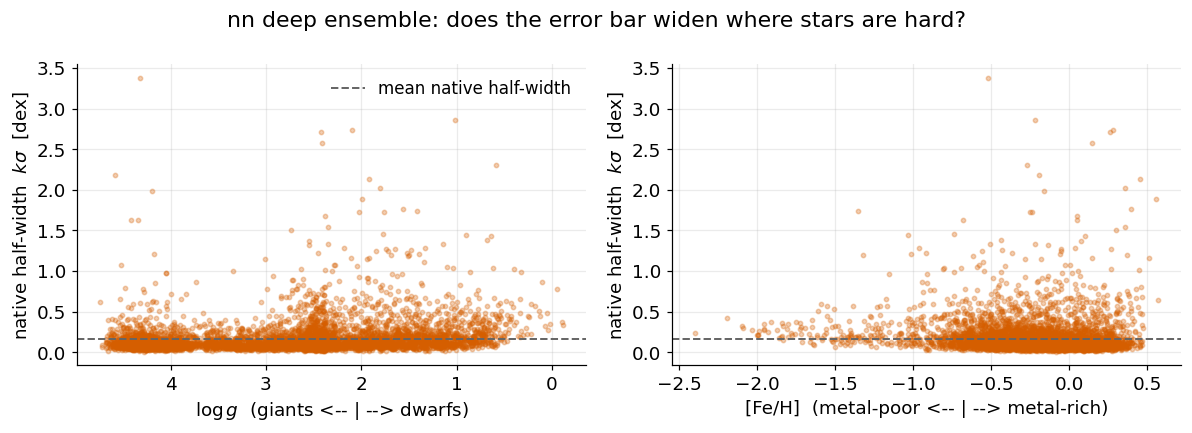

In [5]:
# Does the native half-width climb toward the hard corners (giants, metal-poor)?
half = k * sigma_test
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(logg_test, half, s=8, alpha=0.3, color=COLORS["nn"])
axes[0].axhline(half.mean(), ls="--", color="0.4", lw=1.3, label="mean native half-width")
axes[0].set_xlabel(r"$\log g$  (giants <-- | --> dwarfs)")
axes[0].set_ylabel(r"native half-width  $k\sigma$  [dex]")
axes[0].invert_xaxis(); axes[0].legend()
axes[1].scatter(feh_test, half, s=8, alpha=0.3, color=COLORS["nn"])
axes[1].axhline(half.mean(), ls="--", color="0.4", lw=1.3)
axes[1].set_xlabel(r"[Fe/H]  (metal-poor <-- | --> metal-rich)")
axes[1].set_ylabel(r"native half-width  $k\sigma$  [dex]")
fig.suptitle("nn deep ensemble: does the error bar widen where stars are hard?")
fig.tight_layout(); plt.show()

## 3 · The fudge factor: calibrate your native σ (your turn — the core skill)

Your native σ(x) has the right **shape** (which stars are uncertain) but the wrong **scale** — at face
value it badly **under-covers** (the spread is too tight, because the shared noise cancelled). We fix the
scale with **one scalar `c`**: the calibrated band is

> `prediction ± c · k · σ(x)`

`c` stretches *every* interval by the same factor, so it leaves the **shape** alone (giants still wider
than dwarfs) and only sets the overall **scale**.

**The honest protocol** (the same one from the common notebook):

1. **Sweep `c` on the calibration set** — truths we're allowed to peek at — and find the `c` whose
   calibration coverage lands on 90%.
2. **Apply that `c` to the test set** and report coverage there. Tuning on test would be cheating.

This "tune on cal, report on test" move is exactly the seed of conformal prediction in Notebook 4 — there
you'll replace the hand-tuned `c` with a *guaranteed* version of the same knob.

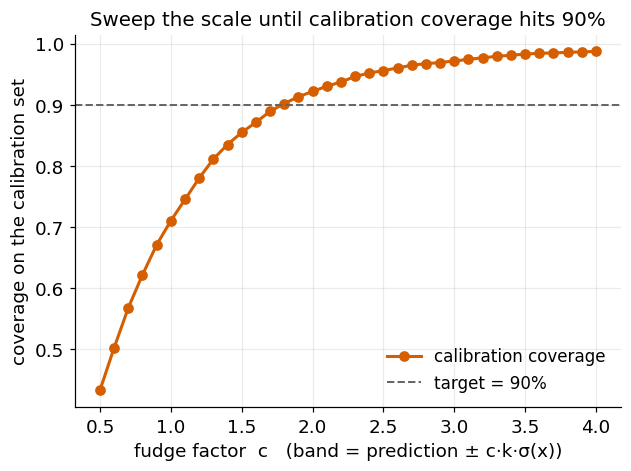

chosen c = 1.00
   calibration coverage at this c = 71.0%
   TEST coverage at this c        = 71.2%   (target = 90%)
   compare -- shared constant floor was 92.3% on test


In [6]:
# Sweep the fudge factor c on the CALIBRATION set, then read coverage on test.
# (Native sigma UNDER-covers at c=1, so expect the crossing to be at c > 1.)
c_grid = np.linspace(0.5, 4.0, 36)
cal_cov = np.array([empirical_coverage(y_cal_feh,
                                       y_pred_cal - c * k * sigma_cal,
                                       y_pred_cal + c * k * sigma_cal) for c in c_grid])

fig, ax = plt.subplots()
ax.plot(c_grid, cal_cov, "o-", color=COLORS["nn"], label="calibration coverage")
ax.axhline(TARGET_LEVEL, ls="--", color="0.4", lw=1.3, label=f"target = {TARGET_LEVEL:.0%}")
ax.set_xlabel(r"fudge factor  c   (band = prediction ± c·k·σ(x))")
ax.set_ylabel("coverage on the calibration set")
ax.set_title("Sweep the scale until calibration coverage hits 90%")
ax.legend(); plt.show()

# Read off the c where the calibration curve crosses the target line, then set it here:
c_fudge = 1.0    # <- your turn: change this to the c that lands CAL coverage on 90% (it will be > 1)

# Apply the SAME c to the TEST set and check coverage honestly.
native_lower = y_pred_test - c_fudge * k * sigma_test
native_upper = y_pred_test + c_fudge * k * sigma_test
cov_native = empirical_coverage(y_test_feh, native_lower, native_upper)
cal_cov_c  = empirical_coverage(y_cal_feh, y_pred_cal - c_fudge*k*sigma_cal, y_pred_cal + c_fudge*k*sigma_cal)
print(f"chosen c = {c_fudge:.2f}")
print(f"   calibration coverage at this c = {cal_cov_c:.1%}")
print(f"   TEST coverage at this c        = {cov_native:.1%}   (target = {TARGET_LEVEL:.0%})")
print(f"   compare -- shared constant floor was {cov_shared:.1%} on test")

## 4 · Did it work? Coverage, reliability, and sharpness

We judge the calibrated native interval on three things:

1. **Marginal coverage** — one number vs the 90% target (we just hit it on test).
2. **Reliability across the data** — is it honest *everywhere* (every `log g`, every `[Fe/H]`), not just
   on average? This is **conditional** coverage, and it's where the average hides things.
3. **Sharpness** — define **width** = `upper − lower`; narrower is better, *but only if coverage holds*.

The headline idea, one more time: **marginal ≠ conditional.** Let's slice and look.

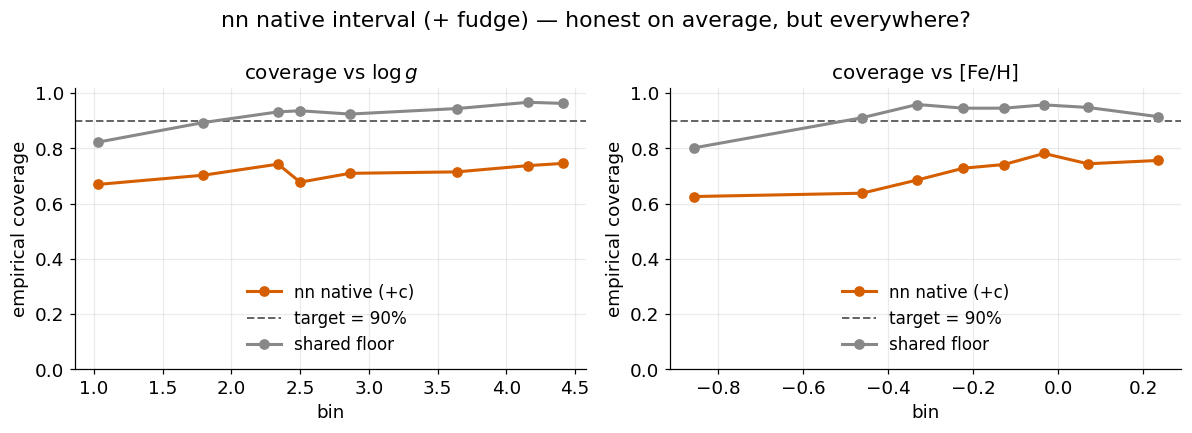

In [7]:
# Slice coverage of YOUR calibrated native interval by both physical axes, with the shared floor
# overlaid for comparison.  plot_reliability bins the stars and shows coverage per bin vs the target.
lo_plot, hi_plot = native_lower, native_upper      # <- your turn: also try shared_lower, shared_upper
                                                   #    (the flat floor) and compare the two curves

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_reliability(y_test_feh, lo_plot, hi_plot, target=TARGET_LEVEL,
                 feature=logg_test, feature_name=r"$\log g$  (giants <-- | --> dwarfs)",
                 ax=axes[0], color=COLORS["nn"], label="nn native (+c)")
plot_reliability(y_test_feh, shared_lower, shared_upper,
                 feature=logg_test, ax=axes[0], color=COLORS["linear"], label="shared floor")
axes[0].set_title(r"coverage vs $\log g$"); axes[0].legend(loc="lower center")
plot_reliability(y_test_feh, lo_plot, hi_plot, target=TARGET_LEVEL,
                 feature=feh_test, feature_name=r"[Fe/H]  (metal-poor <-- | --> metal-rich)",
                 ax=axes[1], color=COLORS["nn"], label="nn native (+c)")
plot_reliability(y_test_feh, shared_lower, shared_upper,
                 feature=feh_test, ax=axes[1], color=COLORS["linear"], label="shared floor")
axes[1].set_title("coverage vs [Fe/H]"); axes[1].legend(loc="lower center")
fig.suptitle("nn native interval (+ fudge) — honest on average, but everywhere?")
fig.tight_layout(); plt.show()
# <- look for: which bins sag BELOW the 90% line? Giants (low log g)? Metal-poor (low [Fe/H])?

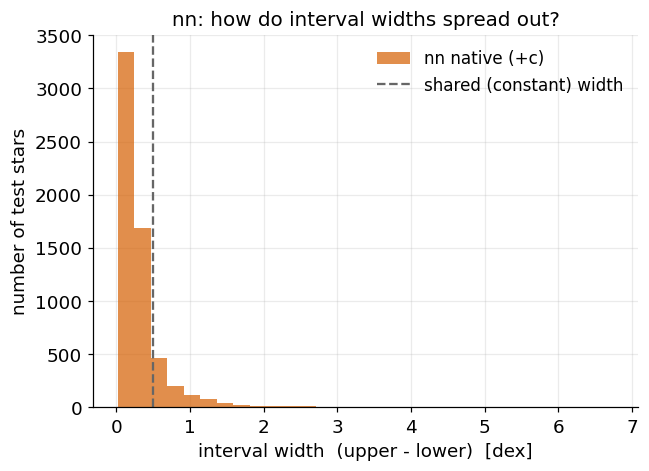

median native width = 0.221 dex   vs   constant width = 0.498 dex


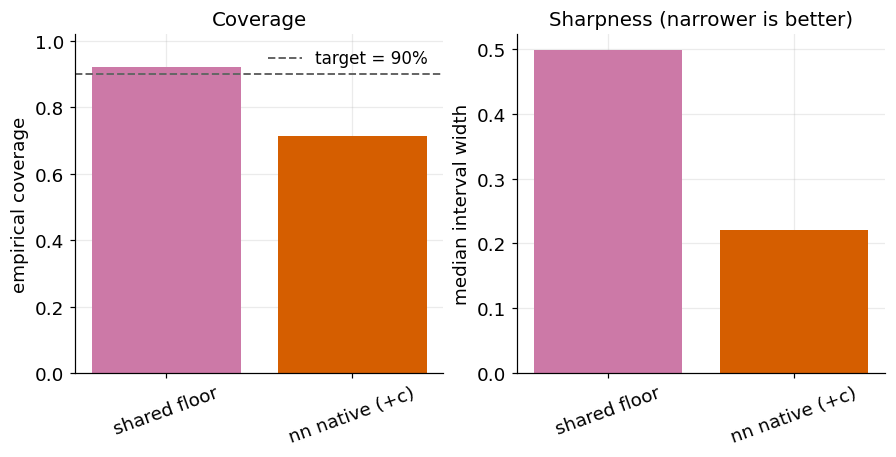

                coverage  median_width
method                                
shared floor    0.922667      0.497834
nn native (+c)  0.712333      0.220888


In [8]:
# Sharpness: the shared floor is ONE width (a spike); your native widths form a DISTRIBUTION.
native_w = native_upper - native_lower
shared_w = shared_upper - shared_lower
fig, ax = plt.subplots()
ax.hist(native_w, bins=30, alpha=0.7, color=COLORS["nn"], label="nn native (+c)")
ax.axvline(shared_w.mean(), ls="--", color="0.4", lw=1.5, label="shared (constant) width")
ax.set_xlabel("interval width  (upper - lower)  [dex]"); ax.set_ylabel("number of test stars")
ax.set_title("nn: how do interval widths spread out?")
ax.legend(); plt.show()
print(f"median native width = {np.median(native_w):.3f} dex   vs   constant width = {shared_w[0]:.3f} dex")

# Coverage AND width together (coverage without width is meaningless: a +/-inf band covers 100%).
tbl = compare_intervals(y_test_feh,
                        {"shared floor": (shared_lower, shared_upper),
                         "nn native (+c)": (native_lower, native_upper)},
                        target=TARGET_LEVEL)
plt.show()
print(tbl)
# <- look for: the native widths form a DISTRIBUTION (adaptive); the shared band is one spike.
#    Are the widest intervals the ones you'd WANT wide (giants, metal-poor)?

## 5 · Explore (open prompts)

No single right answer — bring one annotated plot to the debrief.

1. **Aleatoric or epistemic?** Plot your per-star `sigma_test` across the **Kiel plane** (Teff vs
   `log g`). Does it grow *smoothly* with metallicity (aleatoric, heteroscedastic) or **spike** in the
   sparse giant / metal-poor-halo corner (epistemic)? A deep ensemble's spread is mostly *epistemic* — do
   you see it concentrate in the sparse corners?
2. **Where is it over/under-confident?** Find the test stars where the truth fell *outside* your
   calibrated interval. Are they clustered (giants? metal-poor?) or scattered? What would you tell someone
   relying on those predictions?
3. **(Stretch) Ensemble size.** Re-run §2 with `N_MEMBERS = 3` and `N_MEMBERS = 8`. How much does the
   median σ — and the fudge factor `c` — move? Is 5 members enough?

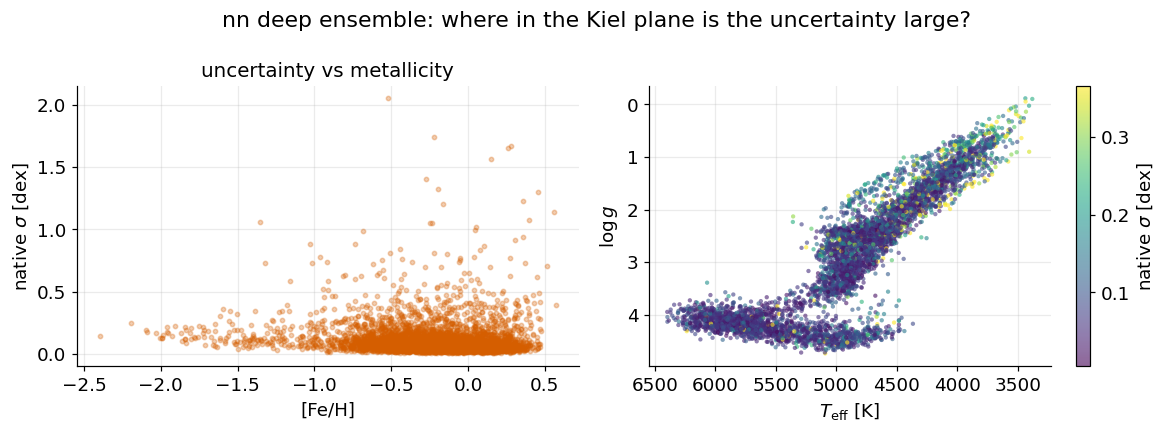

In [9]:
# A starting point for prompt 1 — extend it however you like.
Teff_test = sp["y_test"]["Teff"].to_numpy()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(feh_test, sigma_test, s=8, alpha=0.3, color=COLORS["nn"])
axes[0].set_xlabel(r"[Fe/H]"); axes[0].set_ylabel(r"native $\sigma$ [dex]")
axes[0].set_title("uncertainty vs metallicity")
sc = axes[1].scatter(Teff_test, logg_test, c=sigma_test, s=8, alpha=0.6,
                     vmax=np.quantile(sigma_test, 0.97))   # clip the colour scale so a few huge sigmas don't wash it out
axes[1].set_xlabel(r"$T_\mathrm{eff}$ [K]"); axes[1].set_ylabel(r"$\log g$")
axes[1].invert_xaxis(); axes[1].invert_yaxis()
fig.colorbar(sc, ax=axes[1], label=r"native $\sigma$ [dex]")
fig.suptitle("nn deep ensemble: where in the Kiel plane is the uncertainty large?")
fig.tight_layout(); plt.show()
# <- your turn: which corner has the biggest sigma? The sparse giant branch? The metal-poor halo?

## 6 · Save your calibrated native interval for Notebook 4

Notebook 4 will **conformalize** this same network and compare against today's native interval, so we
save the calibrated native interval (the **fudged** one — `± c·k·σ(x)`) in the locked schema:

`outputs/nn_native_intervals.npz` with keys `y_test_true, lower, upper, target`.

In [10]:
path = save_outputs("nn_native_intervals.npz",
                    y_test_true=y_test_feh,
                    lower=native_lower,
                    upper=native_upper,
                    target=TARGET_LEVEL)
print("saved ->", path)

# Sanity re-load so you SEE the contract Notebook 4 will read:
chk = load_outputs("nn_native_intervals.npz")
print("keys:", list(chk.keys()),
      "| coverage re-check:",
      f"{empirical_coverage(chk['y_test_true'], chk['lower'], chk['upper']):.1%}",
      "| target:", float(chk["target"]))

saved -> /mnt/c/Users/joshs/Dropbox/GitHub/utssrp-2026/outputs/nn_native_intervals.npz
keys: ['y_test_true', 'lower', 'upper', 'target'] | coverage re-check: 71.2% | target: 0.9


## Recap & the cliffhanger

**What you did:** read a **per-star** uncertainty out of your network via a **deep ensemble** (the
sklearn-native route), saw its raw scale **under-cover** badly, **calibrated** it with one fudge factor
`c` tuned honestly on the calibration set, and checked coverage, reliability, and sharpness.

**What you found:** the fudge factor fixes **marginal** coverage (~90% on test), and the per-star widths
*adapt* — but the **conditional gap survives**: the metal-poor stars and luminous giants are still
under-covered. The ensemble spread is mostly **epistemic** and doesn't fully track the heteroscedastic
**aleatoric** widening that makes those stars hard.

**The open problem for Notebook 4:** can we **guarantee** a coverage level *without* trusting a Gaussian
assumption or a hand-tuned `c` — and does that close the giant / metal-poor gap, or only the average?
→ **conformal prediction.** *(Preview: it fixes the average; the conditional gap survives — that's the
poster headline.)*

The optional stretches below go deeper: perturbing the **inputs** within their measurement noise
(input Monte Carlo), predicting **several labels at once**, and the real thing — **Monte-Carlo dropout in
PyTorch**, the deep-learning cousin of today's ensemble.

### What got saved today

- `outputs/nn_native_intervals.npz` — keys `y_test_true, lower, upper, target` (feeds Notebook 4).
- Figures in `figures/` (solution): `nn_fudge_factor_sweep.png`, `nn_native_reliability.png`.

These feed Notebook 4 and the poster.

## Stretch 1 (optional) · Input Monte Carlo — propagate the *measurement* noise

The deep ensemble varied the **model** (different seeds). A different question: how much of your
uncertainty comes from **noise in the inputs**? Each star's 110 Gaia XP coefficients have **measurement
errors** (the catalog stores them). If we **perturb each star's coefficients within its own errors** and
re-predict many times, the spread of those predictions is an **input-propagated** uncertainty — a slice of
the *aleatoric* noise the ensemble could not see (because every member trained on the same fixed inputs).

The helper **`load_input_errors()`** returns the per-coefficient error array `Xerr` (shape `(N, 110)`) for
the stars from the last `load_data()` call, on the **raw** coefficient scale. So we perturb the **raw**
coefficients, re-normalise, and predict — using your **tuned network** (`pipe`).

input-MC sigma: median = 0.073 dex, range = [0.024, 0.286]   (on 500 stars)


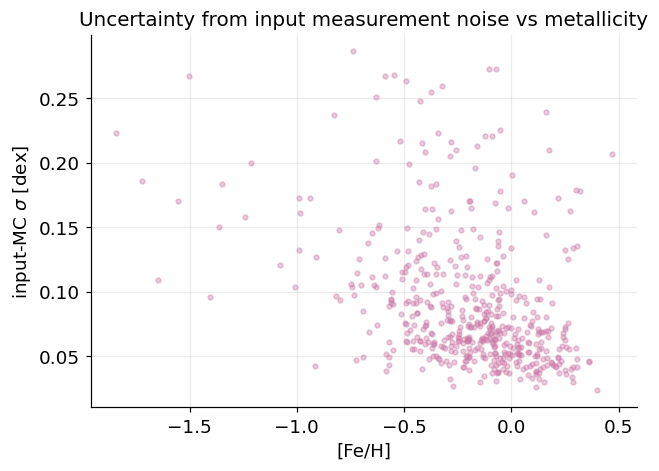

In [11]:
# Per-coefficient measurement errors for the stars we loaded (raw scale), aligned to load_data rows.
Xerr = load_input_errors()
if Xerr is None:
    print("This dataset has no stored input errors (Xerr) — skip this stretch.")
else:
    idx_te   = sp["idx_test"]                       # test-row indices into the load_data() arrays
    Xraw_te  = X[idx_te]                            # RAW (un-normalised) test coefficients
    Xerr_te  = Xerr[idx_te]                         # their per-coefficient errors, same shape
    gflux_te = meta["gflux"].to_numpy()[idx_te]     # brightness scale, to re-normalise after perturbing

    # Keep it fast: a few hundred test stars, ~30 Monte-Carlo draws.
    n_stars  = 500
    n_draws  = 30                                   # <- your turn: try 10 vs 60 and watch sigma steady
    rng_in   = np.random.default_rng(0)
    Xr, Xe, gf = Xraw_te[:n_stars], Xerr_te[:n_stars], gflux_te[:n_stars]

    sims = []
    for _ in range(n_draws):
        Xpert = Xr + rng_in.normal(0.0, 1.0, Xr.shape) * Xe     # jitter each coefficient within its error
        Xpn   = normalize_by_g(Xpert, gf)                       # SAME recipe as everywhere
        sims.append(pipe.predict(Xpn))                          # your tuned network's prediction
    sims = np.stack(sims)                                       # shape (n_draws, n_stars)

    sigma_input = sims.std(axis=0)        # <- your turn: per-star input-propagated scale (std across draws)
    print(f"input-MC sigma: median = {np.median(sigma_input):.3f} dex, "
          f"range = [{sigma_input.min():.3f}, {sigma_input.max():.3f}]   (on {n_stars} stars)")

    fig, ax = plt.subplots()
    ax.scatter(feh_test[:n_stars], sigma_input, s=10, alpha=0.4, color=COLORS["accent"])
    ax.set_xlabel("[Fe/H]"); ax.set_ylabel(r"input-MC $\sigma$ [dex]")
    ax.set_title("Uncertainty from input measurement noise vs metallicity")
    plt.show()

## Stretch 2 (optional) · Multi-label uncertainty — predict several labels at once

So far we've quantified uncertainty on **[Fe/H]** alone. Real stellar-label pipelines predict
**Teff, log g, and [Fe/H] together** — they're physically linked, and a multi-output model can share
information across them. `MLPRegressor` is natively multi-output: hand it a 2-D target and it predicts a
vector. The deep-ensemble UQ recipe carries over unchanged — the spread is now **per label**.

**One essential gotcha — standardise the targets.** Teff is in the thousands (of kelvin), `log g` and
`[Fe/H]` are order-1 (dex). A neural net minimises one squared-error loss summed over all three outputs,
so the giant Teff numbers would **swamp** the loss and the network would barely learn the small labels. So
we **z-score each target** (subtract its mean, divide by its spread) before training, then **un-scale** the
predictions afterwards. (The inputs are already standardised inside `make_model`; this fixes the *output*
side.)

Below, an ensemble predicts all three standardised labels and reports a per-star σ for **each** (back in
physical units). Keep it on the same ~5k subsample for speed.

In [12]:
LABELS = ["Teff", "logg", "FeH"]
Y_sub  = sp["y_train"][LABELS].to_numpy()[sub]        # (5000, 3) multi-output target on the SAME subsample
Y_test = sp["y_test"][LABELS].to_numpy()              # (n_test, 3) truths

members_multi = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for s in range(N_MEMBERS):
        m = make_model("nn", random_state=s)          # multi-output: target is (n, 3)
        m.fit(X_sub, Y_sub)
        members_multi.append(m.predict(sp["X_test"])) # (n_test, 3)
members_multi = np.stack(members_multi)               # (N_MEMBERS, n_test, 3)

pred_multi  = members_multi.mean(axis=0)              # (n_test, 3) point predictions
sigma_multi = members_multi.std(axis=0)               # (n_test, 3) per-star, per-label spread

print("median ensemble sigma per label (raw, before any fudge factor):")
for j, lab in enumerate(LABELS):
    print(f"  {lab:5s}: median sigma = {np.median(sigma_multi[:, j]):.3g}  (units of {lab})")
# <- your turn: which label is the ensemble most UNSURE about, relative to that label's spread?
#    (Tip: compare median sigma to that label's std: np.std(Y_test[:, j]).)

median ensemble sigma per label (raw, before any fudge factor):
  Teff : median sigma = 1.92e+03  (units of Teff)
  logg : median sigma = 1.54  (units of logg)
  FeH  : median sigma = 0.483  (units of FeH)


## Stretch 3 (optional, the special NN stretch) · Proper Monte-Carlo dropout in PyTorch

Earlier we said sklearn's MLP **can't** do Monte-Carlo dropout — and that's true. But the real technique
is worth seeing done **properly**, so here it is in **PyTorch**.

**The idea (Gal & Ghahramani 2016).** *Dropout* randomly zeroes a fraction of neurons during training, to
regularise. Normally you turn dropout **off** at prediction time. MC-dropout does the opposite: keep
dropout **on** at prediction time and run the network **many times** — each pass drops a different random
subset of neurons, giving a slightly different prediction. The **spread across passes** is an uncertainty
that approximates a Bayesian posterior. It's the deep-learning cousin of today's ensemble: instead of many
*networks*, one network sampled many *ways*.

We give you the **model class** (`nn.Dropout` layers, kept active at inference) and the **training loop**
as scaffold. Your job is the UQ part you've now done twice: **sample the MC passes**, turn them into a
per-star σ, and **calibrate with a fudge factor** the same "tune on cal, report on test" way.

Trains on the same ~5k subsample for speed (a few seconds on CPU).

In [13]:
# ---------- PROVIDED SCAFFOLD: a small dropout MLP + its training loop (read, then run) ----------
import torch
import torch.nn as nn

torch.manual_seed(0)

# Standardize the inputs (StandardScaler-equivalent), fit on the SAME 5k subsample, as float32 tensors.
_mu = X_sub.mean(axis=0, keepdims=True); _sd = X_sub.std(axis=0, keepdims=True); _sd[_sd < 1e-12] = 1.0
def _to_t(A): return torch.tensor(((A - _mu) / _sd).astype("float32"))
Xtr_t  = _to_t(X_sub);          ytr_t  = torch.tensor(y_sub.astype("float32")).view(-1, 1)
Xcal_t = _to_t(sp["X_cal"]);    Xte_t  = _to_t(sp["X_test"])

class DropoutMLP(nn.Module):
    """Same (64, 64) shape as your sklearn net, but with Dropout after each hidden layer."""
    def __init__(self, d_in=110, width=64, p=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, width), nn.ReLU(), nn.Dropout(p),    # dropout layer 1
            nn.Linear(width, width), nn.ReLU(), nn.Dropout(p),   # dropout layer 2
            nn.Linear(width, 1),
        )
    def forward(self, x):
        return self.net(x)

mc_model = DropoutMLP(p=0.2)
opt   = torch.optim.Adam(mc_model.parameters(), lr=1e-3, weight_decay=1e-4)
lossf = nn.MSELoss()

# Train WITH dropout ON (model.train() enables dropout). Mini-batch SGD, ~40 epochs.
n, bs = Xtr_t.shape[0], 256
mc_model.train()
for epoch in range(40):
    perm = torch.randperm(n)
    for i in range(0, n, bs):
        b = perm[i:i + bs]
        opt.zero_grad()
        loss = lossf(mc_model(Xtr_t[b]), ytr_t[b])
        loss.backward(); opt.step()
print(f"trained dropout MLP — final mini-batch MSE = {loss.item():.4f}")

trained dropout MLP — final mini-batch MSE = 0.0170


In [14]:
# Keep dropout ON at inference, then run T forward passes -> a distribution per star.
mc_model.train()                                  # <- IMPORTANT: dropout stays ON (do NOT call .eval())
T = 30                                            # <- your turn: number of MC passes (try 10 vs 60)

with torch.no_grad():
    mc_test = np.stack([mc_model(Xte_t).numpy().ravel()  for _ in range(T)])   # (T, n_test)
    mc_cal  = np.stack([mc_model(Xcal_t).numpy().ravel() for _ in range(T)])   # (T, n_cal)

# <- your turn: mean across passes = point prediction; std across passes = per-star sigma (axis=0).
mc_pred_test = mc_test.mean(axis=0);  mc_sigma_test = mc_test.std(axis=0)
mc_pred_cal  = mc_cal.mean(axis=0);   mc_sigma_cal  = mc_cal.std(axis=0)
print(f"MC-dropout sigma: median = {np.median(mc_sigma_test):.3f} dex, "
      f"range = [{mc_sigma_test.min():.3f}, {mc_sigma_test.max():.3f}]")

# Calibrate with a fudge factor on the CAL set (same protocol as section 3).
c_grid_mc = np.linspace(0.5, 6.0, 56)
cal_cov_mc = np.array([empirical_coverage(y_cal_feh, mc_pred_cal - c*k*mc_sigma_cal,
                                          mc_pred_cal + c*k*mc_sigma_cal) for c in c_grid_mc])
c_mc = 1.0    # <- your turn: set c to the value whose CAL coverage hits 90% (read it off cal_cov_mc)

mc_lower = mc_pred_test - c_mc * k * mc_sigma_test
mc_upper = mc_pred_test + c_mc * k * mc_sigma_test
print(f"chosen c = {c_mc:.2f}")
print(f"   CAL  coverage at this c = {empirical_coverage(y_cal_feh, mc_pred_cal - c_mc*k*mc_sigma_cal, mc_pred_cal + c_mc*k*mc_sigma_cal):.1%}")
print(f"   TEST coverage at this c = {empirical_coverage(y_test_feh, mc_lower, mc_upper):.1%}   (target {TARGET_LEVEL:.0%})")

MC-dropout sigma: median = 0.052 dex, range = [0.018, 1.168]
chosen c = 1.00
   CAL  coverage at this c = 60.3%
   TEST coverage at this c = 61.4%   (target 90%)


## Further reading

- **Deep ensembles — Lakshminarayanan, Pritzel & Blundell (2017),** *Simple and Scalable Predictive
  Uncertainty Estimation using Deep Ensembles:* https://arxiv.org/abs/1612.01474 — the paper behind §2;
  a few independently-trained networks give a surprisingly good predictive uncertainty.
- **Monte-Carlo dropout — Gal & Ghahramani (2016),** *Dropout as a Bayesian Approximation:*
  https://arxiv.org/abs/1506.02142 — the theory behind Stretch 3 (dropout at test time ≈ Bayesian sampling).
- **Aleatoric vs. epistemic uncertainty — Hüllermeier & Waegeman (2021):**
  https://arxiv.org/abs/1910.09457 — the careful version of the two flavours; ensemble spread is mostly
  epistemic.
- **A Gentle Introduction to Conformal Prediction and Distribution-Free UQ — Angelopoulos & Bates (2021):**
  https://arxiv.org/abs/2107.07511 — §1–2 on empirical coverage and **marginal vs conditional** (the gap
  your reliability plots expose); the principled replacement for the hand-tuned fudge factor, in Notebook 4.
- **scikit-learn — `MLPRegressor`** (no `dropout` parameter; randomness via `random_state`):
  https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html
- **PyTorch — `torch.nn.Dropout`** (the layer Stretch 3 keeps active at inference):
  https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html
- **The paper behind the data — Laroche & Speagle (2025, arXiv:2404.07316):**
  https://arxiv.org/abs/2404.07316 — why XP chemical information fades for the metal-poor halo (the root
  of the heteroscedastic [Fe/H] error your intervals keep meeting).